# OpenCV: Histogram Equalization + Thresholding

This notebook explains why **histogram equalization** helps segmentation, how to do **global equalization vs CLAHE**, and how to threshold using manual value vs Otsu — with plots so you can see what’s happening.

---

## 1) Why histogram equalization?

Microscopy/SEM images often look **washed out**: pixel values live in a narrow band (e.g., 150–220) instead of using the full 0–255 range.   

Histogram equalization stretches intensities so:

- dark becomes darker
- bright becomes brighter
- separation between phases becomes easier → **thresholding works better**

---

## 2) Read image + visualize original

> Note: OpenCV reads grayscale as `uint8` (0–255), which is perfect for histograms.

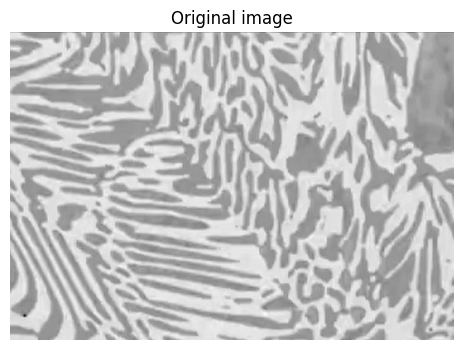

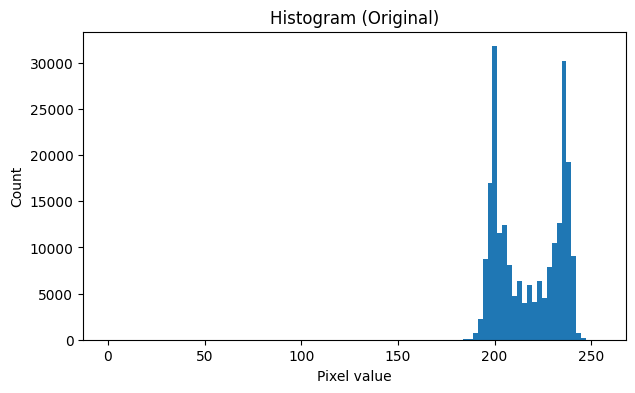

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("images/alloy.jpg", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(6,4))
plt.imshow(img, cmap="gray")
plt.title("Original image")
plt.axis("off")
plt.show()

plt.figure(figsize=(7,4))
plt.hist(img.ravel(), bins=100, range=(0,255))
plt.title("Histogram (Original)")
plt.xlabel("Pixel value")
plt.ylabel("Count")
plt.show()

**What you’ll usually see**: histogram squeezed into a small region → low contrast.

---

## 3) Global histogram equalization

This is **global**: one remapping for the whole image.

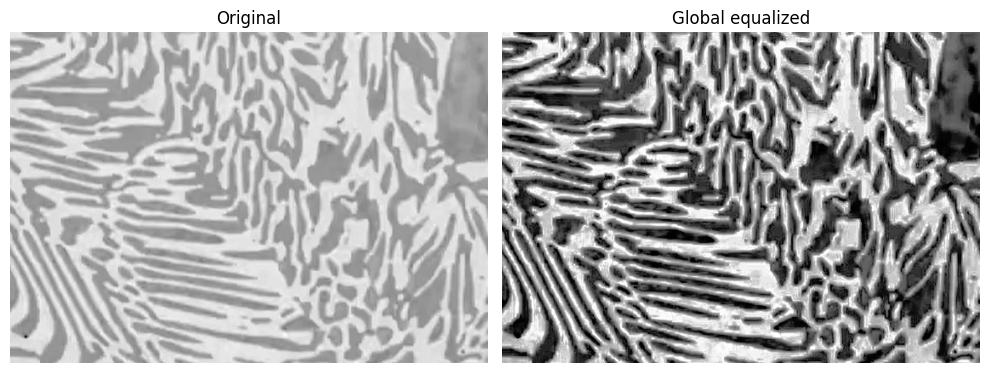

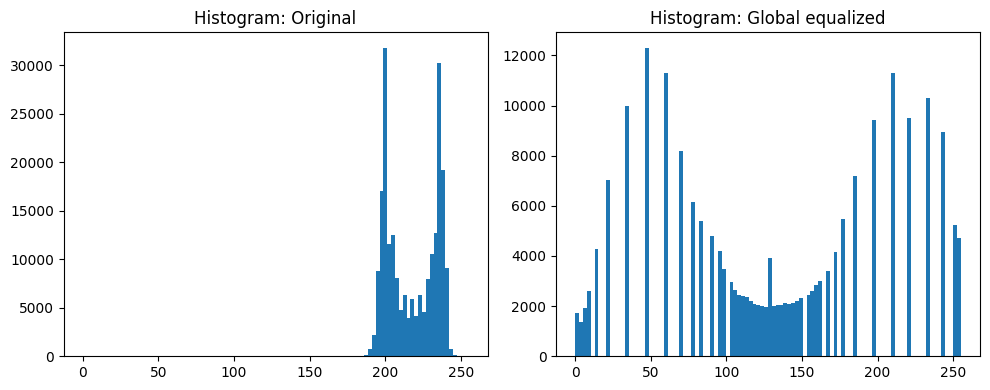

In [4]:
eq = cv2.equalizeHist(img)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); 
plt.imshow(img, cmap="gray"); 
plt.title("Original"); 
plt.axis("off")

plt.subplot(1,2,2); 
plt.imshow(eq, cmap="gray"); 
plt.title("Global equalized"); 
plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(img.ravel(), bins=100, range=(0,255))
plt.title("Histogram: Original")

plt.subplot(1,2,2)
plt.hist(eq.ravel(), bins=100, range=(0,255))
plt.title("Histogram: Global equalized")

plt.tight_layout()
plt.show()



**Why global equalization can look noisy**

When you stretch contrast globally, you also stretch **noise**. If the image already has grain/noise, it becomes more visible.

---

## 4) CLAHE: contrast-limited adaptive equalization (recommended)

CLAHE works in **tiles** (local regions) and limits over-amplification using `clipLimit`.

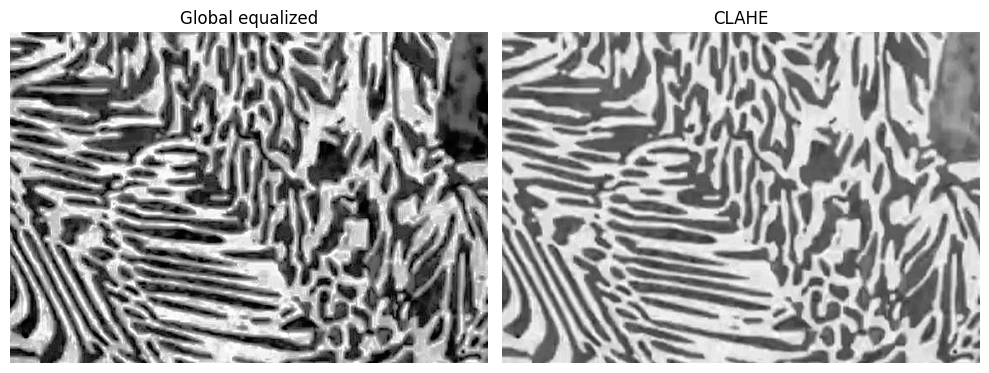

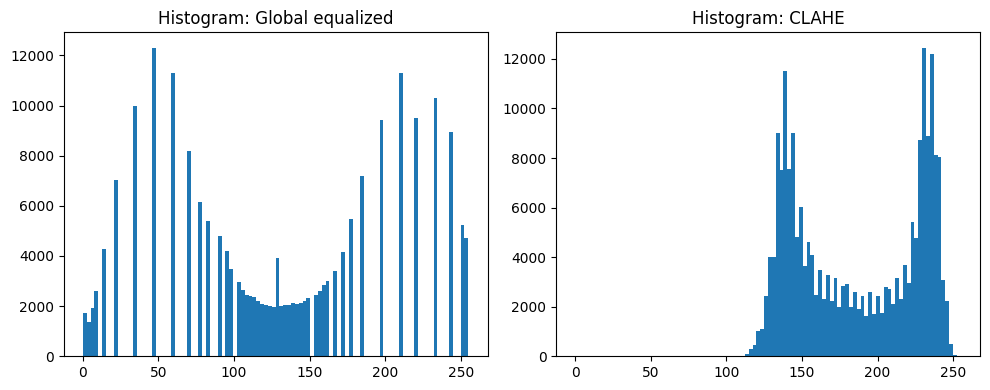

In [9]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl = clahe.apply(img)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1); 
plt.imshow(eq, cmap="gray"); 
plt.title("Global equalized"); 
plt.axis("off")

plt.subplot(1,2,2); 
plt.imshow(cl, cmap="gray"); 
plt.title("CLAHE"); 
plt.axis("off")

plt.tight_layout()
plt.show()


plt.figure(figsize=(10,4))
plt.subplot(1,2,1); 
plt.hist(eq.ravel(), bins=100, range=(0,255)); 
plt.title("Histogram: Global equalized")

plt.subplot(1,2,2); 
plt.hist(cl.ravel(), bins=100, range=(0,255)); 
plt.title("Histogram: CLAHE")

plt.tight_layout()
plt.show()


**Practical CLAHE tips**
- `clipLimit` ↑ → stronger contrast, also more noise
- `tileGridSize` smaller → more local contrast (can look “crispy”)
- `(8,8)` and `clipLimit 2–4` is a solid start

----

## 5) Manual thresholding

Once CLAHE improves separation, we can pick a threshold value.

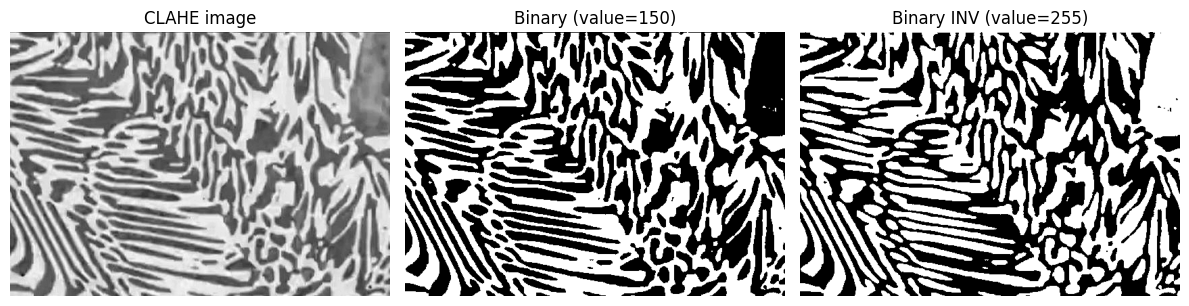

In [6]:
T = 190  # example from histogram valley
_, th1 = cv2.threshold(cl, T, 150, cv2.THRESH_BINARY)
_, th2 = cv2.threshold(cl, T, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1); 
plt.imshow(cl, cmap="gray"); 
plt.title("CLAHE image"); 
plt.axis("off")

plt.subplot(1,3,2); 
plt.imshow(th1, cmap="gray"); 
plt.title("Binary (value=150)"); 
plt.axis("off")

plt.subplot(1,3,3); 
plt.imshow(th2, cmap="gray"); 
plt.title("Binary INV (value=255)"); 
plt.axis("off")

plt.tight_layout()
plt.show()

**Important detail**

The `maxval` (150 vs 255) doesn’t change segmentation logic much, it only changes the label brightness. Most workflows use `255`.

---

## 6) Otsu thresholding

Otsu finds the threshold that best separates two classes by minimizing intra-class variance.

Otsu threshold: 187.0


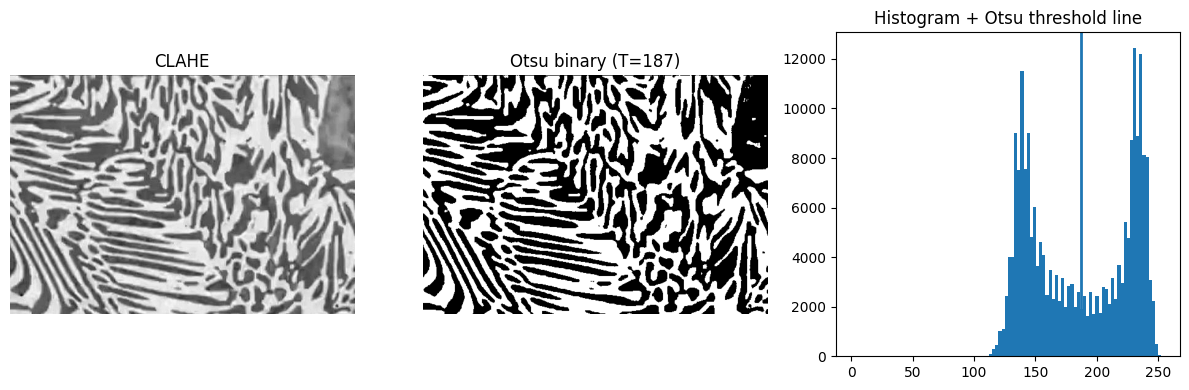

In [7]:
ret_otsu, th_otsu = cv2.threshold(
    cl, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Otsu threshold:", ret_otsu)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1); 
plt.imshow(cl, cmap="gray"); 
plt.title("CLAHE"); 
plt.axis("off")

plt.subplot(1,3,2); 
plt.imshow(th_otsu, cmap="gray"); 
plt.title(f"Otsu binary (T={ret_otsu:.0f})"); 
plt.axis("off")

# Show threshold line on histogram
plt.subplot(1,3,3)
plt.hist(cl.ravel(), bins = 100, range = (0,255))
plt.axvline(ret_otsu, linewidth=2)
plt.title("Histogram + Otsu threshold line")

plt.tight_layout()
plt.show()


**Why manual T (190) differs from Otsu (187)**
- You eyeballed a “valley”
- Otsu optimizes a criterion that may shift the best split slightly
- Both can be valid; choose by segmentation quality (visual + metrics)

---

## 7) Make segmentation cleaner

After thresholding you often get “salt-and-pepper” specks. Clean them with opening/closing.

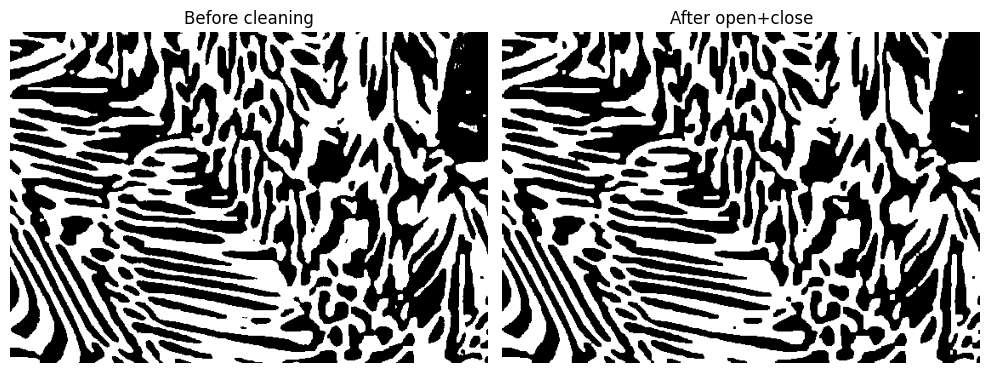

In [8]:
kernel = np.ones((3,3), np.uint8)

clean = cv2.morphologyEx(th_otsu, cv2.MORPH_OPEN, kernel, iterations=1)
clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, kernel, iterations=1)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); 
plt.imshow(th_otsu, cmap="gray"); 
plt.title("Before cleaning"); 
plt.axis("off")

plt.subplot(1,2,2); 
plt.imshow(clean, cmap="gray"); 
plt.title("After open+close"); 
plt.axis("off")

plt.tight_layout()
plt.show()


## 8) Best practice pipeline for these images

A robust workflow for SEM / low-contrast grayscale:
- **Denoise** (optional but recommended): median / bilateral / NLM (skimage)
- **CLAHE** (often best contrast booster)
- **Threshold** (Otsu or manual)
- **Morphology** cleanup
- **Measure** (area fraction, particle stats, etc.)